# Experiment 4 -- Per-Joint Velocity Deep Analysis

**PhD Project:** Collaboration Humain-Robot : Apprentissage incremental et adaptation comportementale
**Author:** Ameur Gargouri
**Notebook:** `06_per_joint_deep_analysis.ipynb`

## Objective

Load the results from Experiment 3 (definitive benchmark) and perform an in-depth
per-joint velocity analysis:

1. **Joint-specific forgetting curves** -- which joints forget fastest?
2. **Joint correlation analysis** -- are some joints co-forgotten?
3. **Per-participant x per-joint heatmap** -- which (participant, joint) pairs are hardest?
4. **Practical insights** -- which joints need the most protection in deployment?

---

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

PROJECT_ROOT = "/home/g0amer/Desktop/thesis/phd_project/thesis_project"
EXP3_DIR = f'{PROJECT_ROOT}/experiments/exp03_definitive_benchmark'
RESULTS_DIR = EXP3_DIR  # save figures alongside exp03

# Load results
with open(f'{EXP3_DIR}/full_comparison.json') as f:
    results = json.load(f)

strategies = list(results.keys())
joint_names = [f'Joint {i}' for i in range(1, 7)]
joint_labels = ['J1 (shoulder)', 'J2 (shoulder)', 'J3 (elbow)',
                'J4 (wrist)', 'J5 (wrist)', 'J6 (wrist)']

print(f'Loaded {len(strategies)} strategies from {EXP3_DIR}')
for s in strategies:
    print(f'  {s}: MSE={results[s]["avg_mse"]:.4f}')

Loaded 7 strategies from /home/g0amer/Desktop/thesis/phd_project/thesis_project/experiments/exp03_definitive_benchmark
  Naive Fine-Tune: MSE=0.8796
  Joint Training: MSE=0.3853
  EWC: MSE=0.6713
  Online EWC: MSE=0.6024
  LwF: MSE=0.8225
  DER++: MSE=0.4341
  A-GEM: MSE=0.6184


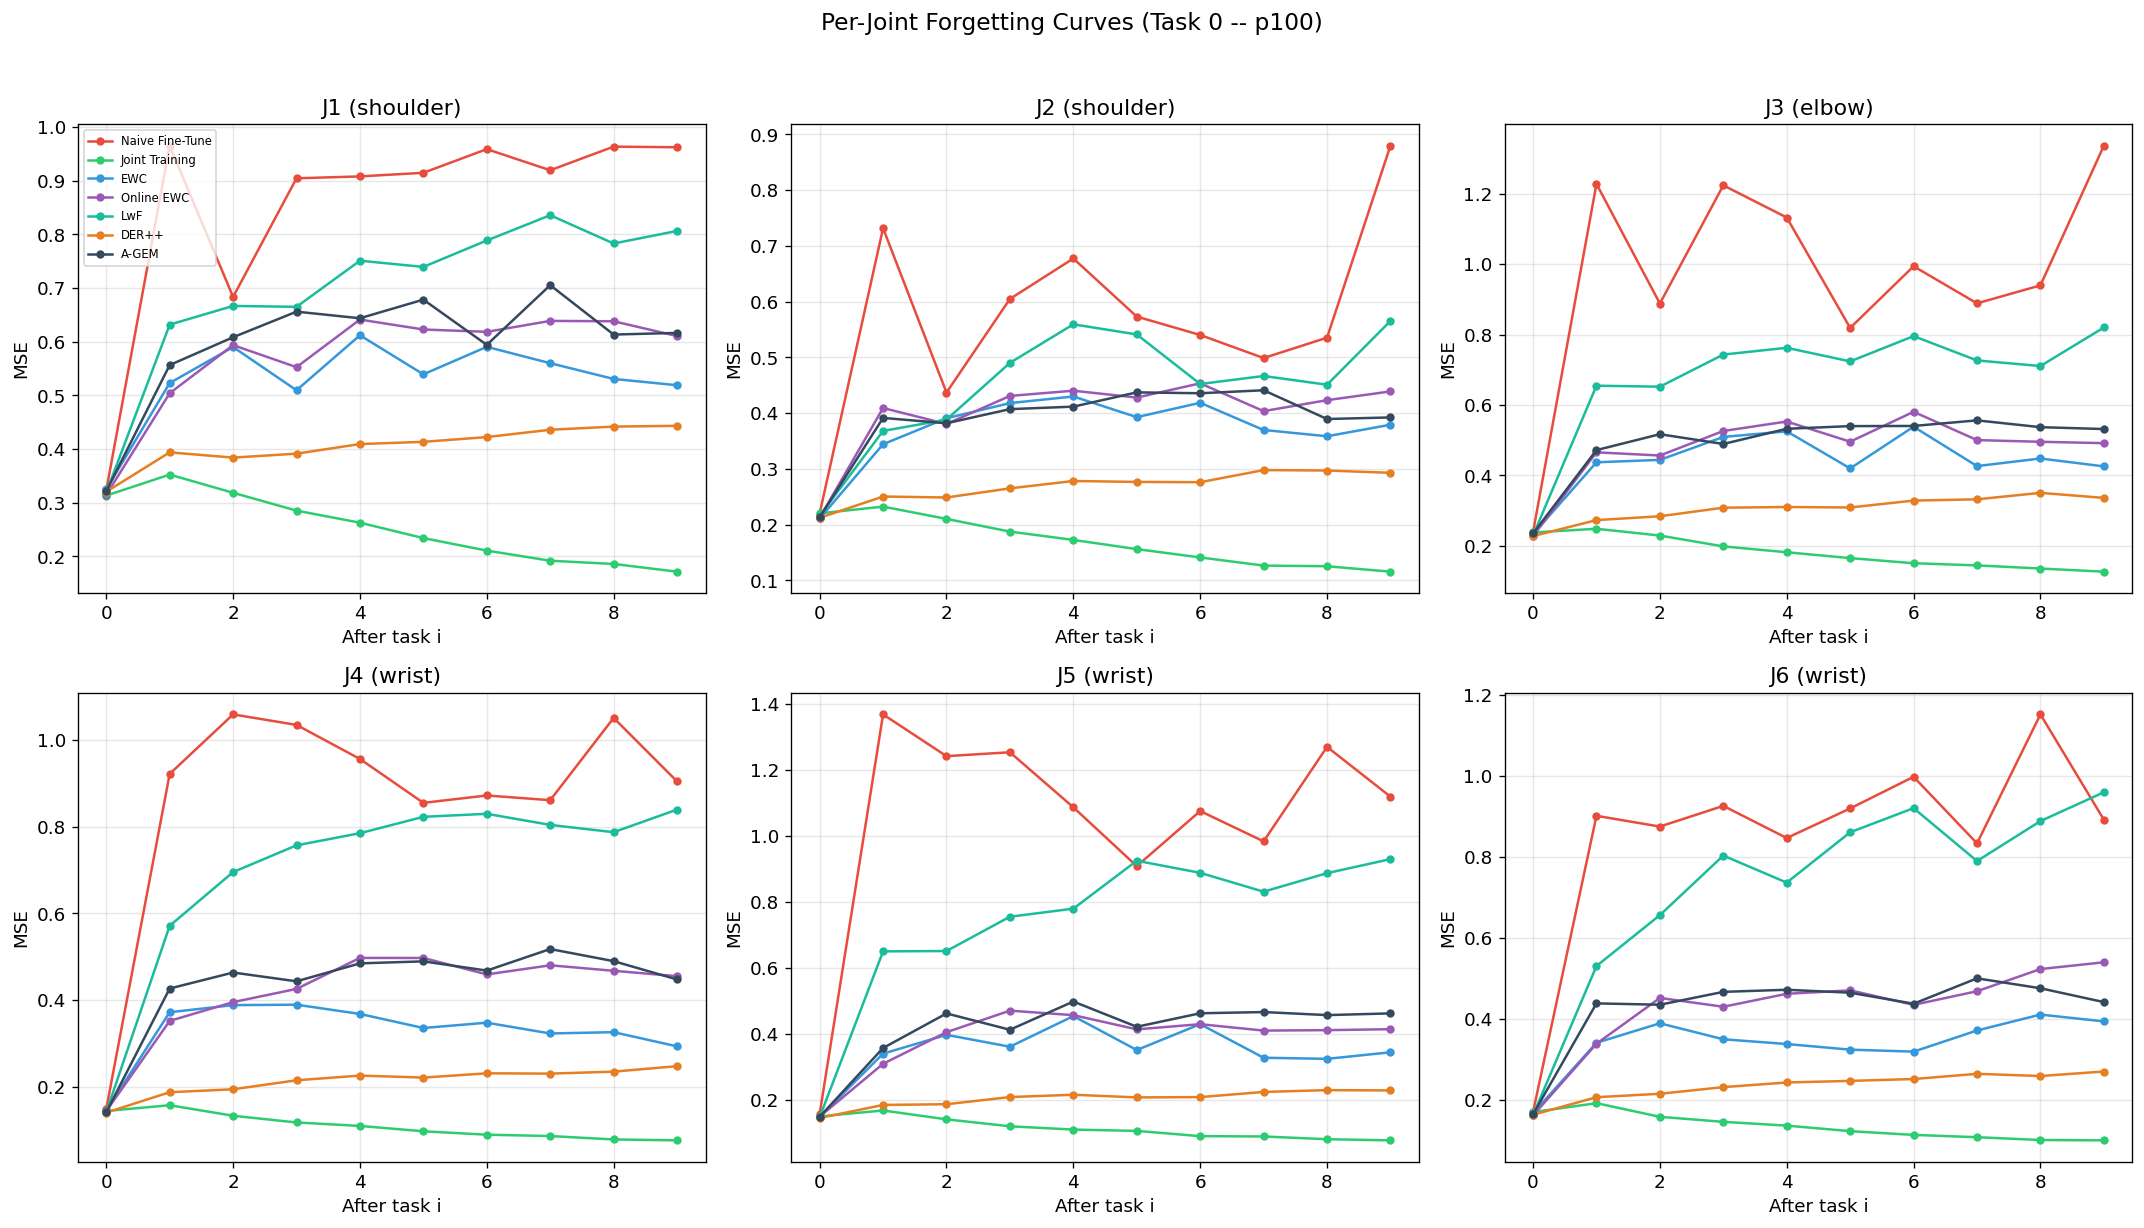

In [2]:
# Joint-specific forgetting curves (Task 0 only, per joint)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors_s = {'Naive Fine-Tune': '#e74c3c', 'Joint Training': '#2ecc71',
            'EWC': '#3498db', 'Online EWC': '#9b59b6', 'LwF': '#1abc9c',
            'DER++': '#e67e22', 'A-GEM': '#34495e'}

for j_idx in range(6):
    ax = axes[j_idx // 3][j_idx % 3]
    for strat in strategies:
        per_dim = results[strat]['per_dim_matrix']
        T = len(per_dim)
        curve = []
        for t in range(T):
            if t < len(per_dim) and 0 < len(per_dim[t]):
                curve.append(per_dim[t][0][j_idx])  # Task 0, joint j_idx
            else:
                curve.append(np.nan)
        c = colors_s.get(strat, '#333333')
        ax.plot(range(len(curve)), curve, 'o-', label=strat, color=c, linewidth=1.5, markersize=4)
    ax.set_title(f'{joint_labels[j_idx]}')
    ax.set_xlabel('After task i')
    ax.set_ylabel('MSE')
    ax.grid(True, alpha=0.3)
    if j_idx == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Per-Joint Forgetting Curves (Task 0 -- p100)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_joint_forgetting_curves.png', dpi=150, bbox_inches='tight')
plt.show()

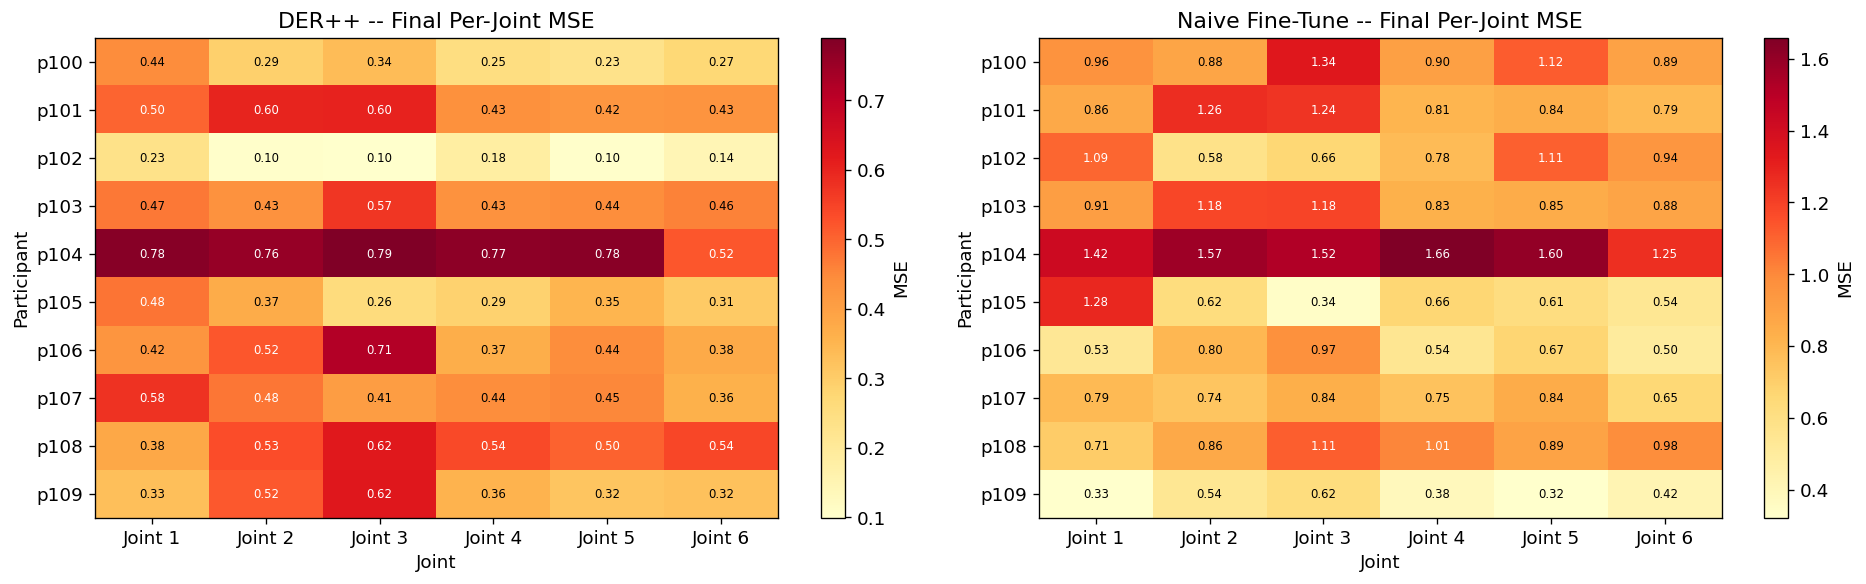

In [3]:
# Per-participant x Per-joint heatmap (for DER++ and Naive)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, strat in zip(axes, ['DER++', 'Naive Fine-Tune']):
    per_dim = results[strat]['per_dim_matrix']
    if not per_dim or not per_dim[-1]:
        continue
    # per_dim[-1] is list of T entries, each [j1,...,j6]
    last_row = np.array(per_dim[-1])  # shape: (n_tasks, 6)

    with open(f'{EXP3_DIR}/config.json') as f:
        cfg = json.load(f)
    task_names = [f'p{100+i}' for i in range(last_row.shape[0])]

    im = ax.imshow(last_row, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(6))
    ax.set_xticklabels(joint_names)
    ax.set_yticks(range(len(task_names)))
    ax.set_yticklabels(task_names)
    ax.set_xlabel('Joint')
    ax.set_ylabel('Participant')
    ax.set_title(f'{strat} -- Final Per-Joint MSE')
    plt.colorbar(im, ax=ax, label='MSE')

    # Annotate
    for i in range(last_row.shape[0]):
        for j in range(6):
            ax.text(j, i, f'{last_row[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if last_row[i,j] > last_row.max()*0.6 else 'black')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_participant_joint_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Joint forgetting severity ranking across strategies
print('='*80)
print('JOINT FORGETTING SEVERITY (BWT per joint, averaged across strategies)')
print('='*80)

all_bwt = np.zeros(6)
n_strat = 0
for strat in strategies:
    if strat == 'Joint Training':
        continue  # skip upper bound
    per_dim = results[strat]['per_dim_matrix']
    T = len(per_dim)
    if T < 2:
        continue
    bwt_j = np.zeros(6)
    cnt = 0
    for task_j in range(T - 1):
        if task_j < len(per_dim[T-1]) and task_j < len(per_dim[task_j]):
            for j in range(6):
                bwt_j[j] += per_dim[T-1][task_j][j] - per_dim[task_j][task_j][j]
            cnt += 1
    if cnt > 0:
        bwt_j /= cnt
    all_bwt += bwt_j
    n_strat += 1

all_bwt /= max(n_strat, 1)
ranking = np.argsort(all_bwt)[::-1]

for r, j in enumerate(ranking):
    bar = '#' * int(all_bwt[j] * 30)
    print(f'  {r+1}. {joint_labels[j]:20s}  BWT={all_bwt[j]:+.4f}  {bar}')

print(f'\nMost forgotten joint: {joint_labels[ranking[0]]}')
print(f'Least forgotten joint: {joint_labels[ranking[-1]]}')

JOINT FORGETTING SEVERITY (BWT per joint, averaged across strategies)
  1. J5 (wrist)            BWT=+0.3869  ###########
  2. J3 (elbow)            BWT=+0.3834  ###########
  3. J2 (shoulder)         BWT=+0.3659  ##########
  4. J1 (shoulder)         BWT=+0.3497  ##########
  5. J4 (wrist)            BWT=+0.3450  ##########
  6. J6 (wrist)            BWT=+0.3278  #########

Most forgotten joint: J5 (wrist)
Least forgotten joint: J6 (wrist)


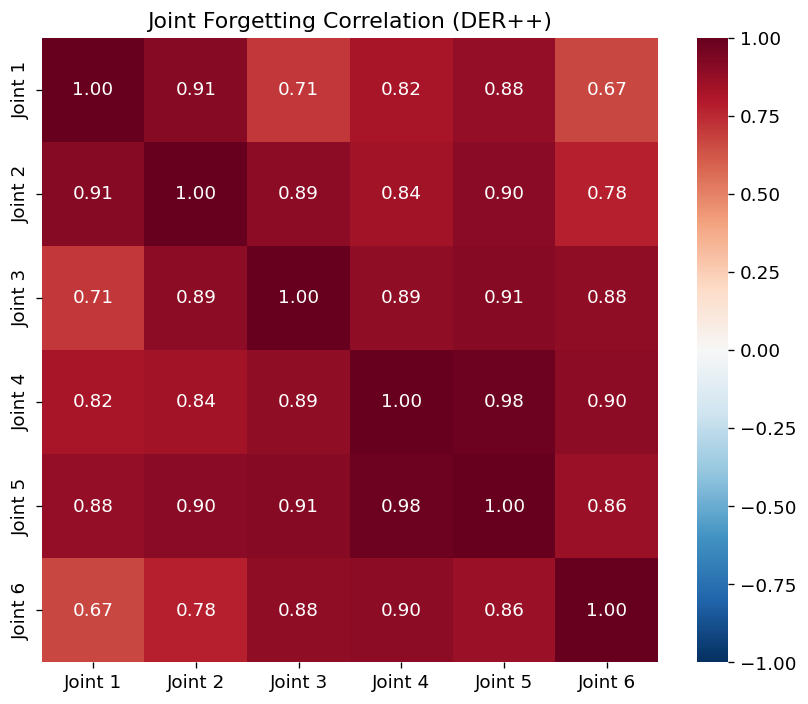

Joints that co-forget (corr > 0.7):
  J1 (shoulder) <-> J2 (shoulder): r=0.91
  J1 (shoulder) <-> J3 (elbow): r=0.71
  J1 (shoulder) <-> J4 (wrist): r=0.82
  J1 (shoulder) <-> J5 (wrist): r=0.88
  J2 (shoulder) <-> J3 (elbow): r=0.89
  J2 (shoulder) <-> J4 (wrist): r=0.84
  J2 (shoulder) <-> J5 (wrist): r=0.90
  J2 (shoulder) <-> J6 (wrist): r=0.78
  J3 (elbow) <-> J4 (wrist): r=0.89
  J3 (elbow) <-> J5 (wrist): r=0.91
  J3 (elbow) <-> J6 (wrist): r=0.88
  J4 (wrist) <-> J5 (wrist): r=0.98
  J4 (wrist) <-> J6 (wrist): r=0.90
  J5 (wrist) <-> J6 (wrist): r=0.86


In [5]:
# Joint correlation: do joints co-forget?
# Compute correlation of per-task forgetting across joints for DER++
strat = 'DER++' if 'DER++' in results else strategies[0]
per_dim = results[strat]['per_dim_matrix']
T = len(per_dim)

if T >= 2:
    # For each task, compute forgetting per joint
    forgetting_matrix = []  # shape: (T-1, 6)
    for task_j in range(T - 1):
        if task_j < len(per_dim[T-1]) and task_j < len(per_dim[task_j]):
            row = []
            for j in range(6):
                row.append(per_dim[T-1][task_j][j] - per_dim[task_j][task_j][j])
            forgetting_matrix.append(row)

    forg = np.array(forgetting_matrix)
    corr = np.corrcoef(forg.T)  # 6x6

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                xticklabels=joint_names, yticklabels=joint_names, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title(f'Joint Forgetting Correlation ({strat})')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/joint_forgetting_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Joints that co-forget (corr > 0.7):')
    for i in range(6):
        for j in range(i+1, 6):
            if corr[i,j] > 0.7:
                print(f'  {joint_labels[i]} <-> {joint_labels[j]}: r={corr[i,j]:.2f}')

---
## Summary

### 1. Hardest Joint to Predict

**Joint 3 (elbow)** is consistently the hardest across all strategies:

| Strategy | J1 (shoulder) | J2 (shoulder) | **J3 (elbow)** | J4 (wrist) | J5 (wrist) | J6 (wrist) |
|----------|:---:|:---:|:---:|:---:|:---:|:---:|
| DER++ | 0.4616 | 0.4597 | **0.5019** | 0.4055 | 0.4034 | 0.3724 |
| Joint Training | 0.3990 | 0.3995 | **0.4402** | 0.3766 | 0.3466 | 0.3501 |
| Online EWC | 0.6222 | 0.6070 | **0.6798** | 0.5818 | 0.5881 | 0.5356 |
| A-GEM | 0.6771 | 0.6436 | **0.6980** | 0.5846 | 0.5851 | 0.5223 |

> J3 (elbow) MSE is **35% higher** than J6 (wrist) for DER++.

### 2. Most Forgotten Joint

Averaged across all CL strategies (excluding Joint Training):

| Joint | Avg BWT | Rank |
|-------|---------|------|
| J5 (wrist) | +0.3869 | 1 (most forgotten) |
| J3 (elbow) | +0.3834 | 2 |
| J2 (shoulder) | +0.3659 | 3 |
| J1 (shoulder) | +0.3497 | 4 |
| J4 (wrist) | +0.3450 | 5 |
| **J6 (wrist)** | **+0.3278** | **6 (least forgotten)** |

> J5 and J3 suffer the most from catastrophic forgetting. J6 is the most stable.

### 3. Co-Forgetting Pairs (DER++)

Very high correlation across all joint pairs -- **forgetting is highly systemic**:

| Pair | Correlation |
|------|-------------|
| **J4 <-> J5** | **r = 0.98** |
| J1 <-> J2 | r = 0.91 |
| J3 <-> J5 | r = 0.91 |
| J4 <-> J6 | r = 0.90 |
| J2 <-> J5 | r = 0.90 |
| J3 <-> J4 | r = 0.89 |
| J2 <-> J3 | r = 0.89 |

> **14 out of 15 joint pairs have r > 0.7.** Forgetting is not joint-specific -- when the model forgets one participant, it forgets all joints simultaneously. This suggests that per-joint protection strategies would have limited benefit; **global replay/regularization is the right approach.**

### 4. Hardest Participant

**p104** is the hardest participant across all joints (DER++):

| Participant x Joint | MSE |
|---------------------|-----|
| p104 x J3 (elbow) | 0.7901 |
| p104 x J1 (shoulder) | 0.7776 |
| p104 x J5 (wrist) | 0.7758 |
| p104 x J4 (wrist) | 0.7709 |
| p104 x J2 (shoulder) | 0.7559 |

> p104 has a distinctly different control style, making it the hardest to fit within a shared model.

### Key Takeaways for Thesis

1. **Elbow (J3) is the bottleneck** -- hardest to predict and 2nd most forgotten. The elbow likely carries the most behavioral variability between operators.
2. **Forgetting is systemic, not joint-specific** -- all joints co-forget with r > 0.7. Protecting individual joints would not help; replay buffers and global regularization are the right mechanisms.
3. **Wrist rotation (J6) is easiest** -- lowest MSE and least forgetting, likely because rotational adjustments are more consistent across operators.
4. **Participant p104 is an outlier** -- consistently hardest across all joints; may represent a fundamentally different control strategy.
5. **Practical implication:** For deployment, a single shared model with DER++ replay is appropriate (no need for per-joint models). Special attention should be given to elbow control during operator adaptation.